# Task 04: Stock Price Prediction
Details: In this task, we will use the data retrieved using the YF API for stock price prediction. 
The idea is to use the latest developments in the field of deep learning such as transformers, hierarchial forecasting and conformal Prediction Models.


The task is divided into 4 steps:
1) Data Preparation
2) Model Development/Fetching Pre-trained Weights
3) Performance Tracking using Tensorflow/WandB weights
4) Inference and its Analysis

At the end, I ll compare the performance of all the models to make sure that we leverage the best performing model.

In [132]:
import yfinance as yf
import pandas as pd
import tensorflow as tf
import wandb
import matplotlib.pyplot as plt

import random
import time
from datetime import datetime
from itertools import product
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MaxAbsScaler
from tqdm.auto import tqdm

from darts import TimeSeries, concatenate
from darts.dataprocessing.transformers import Scaler
from darts.metrics import smape,r2_score
from darts.models import (
    ARIMA,
    LinearRegressionModel,
    NaiveSeasonal,
    NBEATSModel,
)
from darts.utils.losses import SmapeLoss
from darts.utils.callbacks import TFMProgressBar

def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "accelerator": "cpu",
            # "devices": [0],
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }
# GLOBAL VARIABLES
HORIZON = 7 # 7 Days Forecast
TRAIN_TEST_SPLIT_RATIO = 0.8
LOOK_BACK = 30 # Input size 30 Days Chunks

# Helper Functions

In [98]:
# Function to fetch Apple stock data using YF API
def fetch_data(stock_symbol="AAPL", start_date="2010-01-01", end_date="2025-01-01"):
    try:
        print(f"Fetching data for {stock_symbol} from {start_date} to {end_date}...")
        data = yf.download(stock_symbol, start=start_date, end=end_date, progress=False)

        # Check for missing data
        if data.isnull().sum().sum() > 0:
            print("Warning: Missing data found, filling with forward fill method.")

        data = data["Close"].fillna(method="ffill")
        return data
    except Exception as e:
        print(f"Error while fetching data: {e}")
        return None


# Function to convert data to Darts TimeSeries format
def prepare_data(data):
    try:
        print("Preparing data for Darts model...")
        df = pd.DataFrame(data)
        df = df.reset_index()
        df.fillna(method="ffill", inplace=True)
        print("Missing Values: ", df.isnull().sum())
        
        # Convert to Darts TimeSeries object
        # series = TimeSeries.from_dataframe(
        #     df, time_col="Date", value_cols="Close", freq="D"
        # )
        series = TimeSeries.from_dataframe(
            df, time_col=None, value_cols="Close", freq=None
        )
        return series

    except Exception as e:

        print(f"Error during data preparation: {e}")

        return None

In [137]:

# Function to initialize and train N-BEATS model
def train_model(
    series, input_chunk_length=30, output_chunk_length=15, epochs=100, batch_size=64
):
    try:
        print("Initializing and training N-BEATS model...")
        model = NBEATSModel(
            input_chunk_length=input_chunk_length,
            output_chunk_length=output_chunk_length,
            random_state=42,
        )

        # Split the series into training and validation sets
        train, val = series.split_before(0.8)

        # Fit the model with TensorBoard callback
        callback = tf.keras.callbacks.TensorBoard(log_dir="./logs")

        print("Training the model...")
        model.fit(
            train,
            val_series=val,
            epochs=epochs,
            batch_size=batch_size,
            verbose=True,
            callbacks=[callback],
        )

        return model
    except Exception as e:
        print(f"Error during model training: {e}")
        return None


# Function to track performance using WandB
def track_wandb(project_name="apple-stock-forecasting"):
    try:
        wandb.init(project=project_name, entity="your_wandb_entity")
        wandb.config.input_chunk_length = 30
        wandb.config.output_chunk_length = 15
        wandb.config.epochs = 100
        wandb.config.batch_size = 64
    except Exception as e:
        print(f"Error initializing WandB: {e}")


# Function to make and plot predictions
def make_predictions(model, series, forecast_days=15):
    try:
        print(f"Making predictions for the next {forecast_days} days...")
        forecast = model.predict(n=forecast_days)

        # Plot the forecast
        plt.figure(figsize=(10, 6))
        forecast.plot(label=f"{forecast_days} Days Forecast", color="red")
        series.plot(label="Historical Data", color="blue")
        plt.title(f"Apple Stock Price Forecast for Next {forecast_days} Days")
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"Error during prediction: {e}")

def display_forecast(pred_series, ts_transformed, forecast_type, start_date=None):
    plt.figure(figsize=(8, 5))
    if start_date:
        ts_transformed = ts_transformed.drop_before(start_date)
    ts_transformed.univariate_component(0).plot(label="actual")
    pred_series.plot(label=("historic " + forecast_type + " forecasts"))
    plt.title(f"R2: {r2_score(ts_transformed.univariate_component(0), pred_series)}")
    plt.legend()

def eval_forecasts(
    pred_series: list[TimeSeries], test_series: list[TimeSeries]
) -> list[float]:
    print("computing sMAPEs...")
    smapes = smape(test_series, pred_series)
    plt.figure()
    plt.hist(smapes, bins=50)
    plt.ylabel("Count")
    plt.xlabel("sMAPE")
    plt.title(f"Median sMAPE: {np.median(smapes):.3f}")
    plt.show()
    plt.close()
    return smapes

def eval_local_model(
    train_series: list[TimeSeries], test_series: list[TimeSeries], model_cls, **kwargs
) -> tuple[list[float], float]:
    preds = []
    start_time = time.time()
    for series in tqdm(train_series):
        model = model_cls(**kwargs)
        model.fit(series)
        pred = model.predict(n=HORIZON)
        preds.append(pred)
    elapsed_time = time.time() - start_time

    smapes = eval_forecasts(preds, test_series)
    return smapes, elapsed_time

# Create a function to plot time series data
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across timesteps).
  
  Parameters
  ---------
  timesteps : array of timesteps
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (setting a value will index from end of timesteps & values)
  label : label to show on plot of values
  """
  # Plot the series
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Date")
  plt.ylabel("Close")
  if label:
    plt.legend(fontsize=14) # make label bigger
  plt.grid(True)


# 1. Data Preparation
* Please note that I am only using Apple Stock Prices Forecasting for this problem which can be then generalized to any other stocks thanks to the modern tech stack
* Preprocessing involves only fetvhing the closing day prices and filling the missing values usign the forward filling which is a quick way to handle the missing values

Fetching data for AAPL from 2010-01-01 to 2025-01-01...
Preparing data for Darts model...
Missing Values:  Date     0
Close    0
dtype: int64


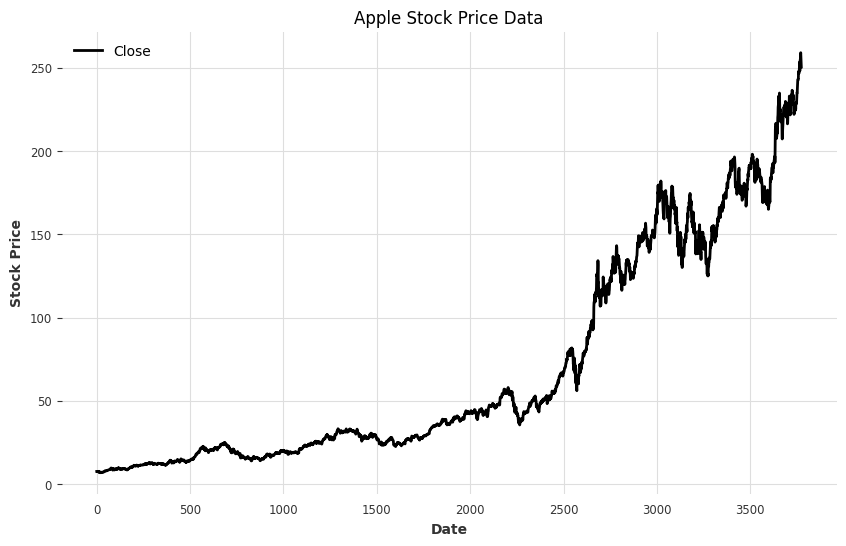

In [138]:
# Fetch data
stock_data = fetch_data()
# Prepare data
series = prepare_data(stock_data)

# Visualize the data
plt.figure(figsize=(10, 6))
series.plot()
plt.title("Apple Stock Price Data")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.show()

# Network Details

## Method
We will try the classical Machine Learning, Statistical Time Series and Deep Learning Model as well. The idea is to try ARIMA, Linear Regression and then NBEATS (SOTA in Time Series).
Due to unavailability of high computational resources, its little difficult to train these models on all of the stocks mentioned in the Data.
The evaluation strategy is very simple to check the mean squared error or R2-score (1 is better and 0 is worse). However, there can be some more buisness sophisticated metrics whcih i will add if got some time in the end.


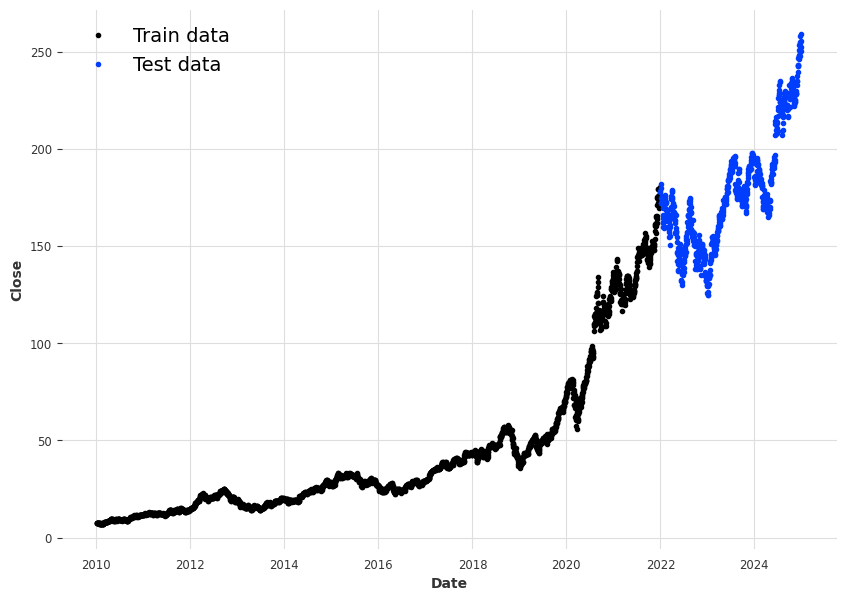

In [139]:
data = pd.DataFrame(stock_data).reset_index()
index = int(len(data)*TRAIN_TEST_SPLIT_RATIO)
train, test = data[:index], data[index:]
# Try out our plotting function
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=train['Date'], values=train['Close'], label="Train data")
plot_time_series(timesteps=test['Date'], values=test['Close'], label="Test data")

#  Training & Evaluation

In [131]:
train_scaled,test_scaled = series.split_after(TRAIN_TEST_SPLIT_RATIO)
model_name = f"nbeats_apple_{HORIZON}_days"
model_nbeats = NBEATSModel(
    input_chunk_length=30,
    output_chunk_length=HORIZON,
    generic_architecture=True,
    num_stacks=10,
    num_blocks=1,
    num_layers=4,
    layer_widths=512,
    n_epochs=100,
    nr_epochs_val_period=1,
    batch_size=800,
    random_state=42,
    model_name=model_name,
    save_checkpoints=True,
    force_reset=True,
    **generate_torch_kwargs(),
)

In [118]:
model_nbeats.fit(train_scaled, val_series=test_scaled)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 8.1 M  | train
-------------------------------------------------------------
8.1 M     Trainable params
2.7 K     Non-trainable params
8.1 M     Total params
32.368    Total estimated model params size (MB)
136       Modules in train mode
0         Modules in eval mode


Epoch 99: 100%|██████████| 4/4 [00:00<00:00,  5.89it/s, train_loss=4.430, val_loss=44.00] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 4/4 [00:01<00:00,  3.80it/s, train_loss=4.430, val_loss=44.00]


NBEATSModel(output_chunk_shift=0, generic_architecture=True, num_stacks=10, num_blocks=1, num_layers=4, layer_widths=512, expansion_coefficient_dim=5, trend_polynomial_degree=2, dropout=0.0, activation=ReLU, input_chunk_length=30, output_chunk_length=7, n_epochs=100, nr_epochs_val_period=1, batch_size=800, random_state=42, model_name=nbeats_apple, save_checkpoints=True, force_reset=True, pl_trainer_kwargs={'accelerator': 'cpu', 'callbacks': [<darts.utils.callbacks.TFMProgressBar object at 0x000001D189E848E0>]})

In [119]:
# Load the best model
model_nbeats = NBEATSModel.load_from_checkpoint(model_name=model_name, best=True)

In [123]:
# Inference
pred_series = model_nbeats.historical_forecasts(
    test_scaled,
    start=test_scaled.start_time(),
    forecast_horizon=7,
    stride=7,
    last_points_only=False,
    retrain=False,
    verbose=True,
)
pred_series = concatenate(pred_series)

`start` time `3019` is before the first predictable/trainable historical forecasting point for series at index: 0. Using the first historical forecasting point `3054` that lies a round-multiple of `stride=7` ahead of `start`. To hide these warnings, set `show_warnings=False`.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


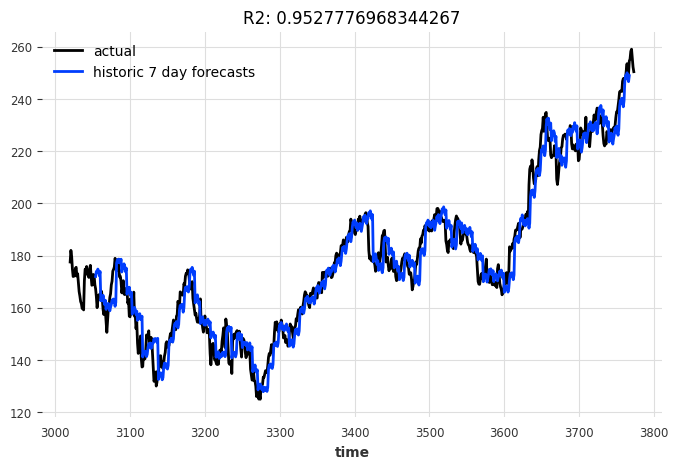

In [130]:
# Visualize the forecast
display_forecast(
    pred_series, test_scaled, "7 day", start_date=test_scaled.start_time()
)